## Imports


In [1]:
import numpy as np
import pandas as pd
import os

## Load board.npy from experiments

In [2]:
# Define path to board.npy
board_path = os.path.join('experiments', 'board.npy')

# Load the file 
board_data = np.load(board_path)
board_df = pd.DataFrame(board_data)
board_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,4,0,2,2,2,0,0,0,0,0,0,0,0,2,0,3
1,0,0,2,2,2,0,0,0,2,2,2,2,2,2,0,0
2,0,0,2,2,2,0,0,0,2,0,0,0,0,2,0,0
3,0,0,2,2,2,2,2,0,2,0,2,2,0,2,0,0
4,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0
5,0,0,2,2,2,0,2,0,2,2,2,0,0,0,0,0
6,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Reward Progression in Episode 0100

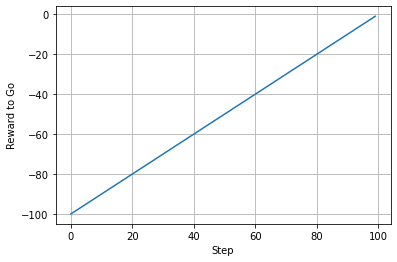

In [17]:
# Load a specific episode's Parquet file
import pyarrow.parquet as pq
from IPython.display import Markdown, display

episode = "0100" # 4 digits expected
episode_df = pq.read_table(f'experiments/experiment_00{episode}.parquet')
episode_data = episode_df.to_pydict()

# Extract Q-table
q_table = np.array(episode_data['experiment'][0]['q_table'])

# Visualize reward progression
display(Markdown(f"# Reward Progression in Episode {episode}"))
import matplotlib.pyplot as plt
rewards_to_go = [step['reward_to_go'] for step in steps]
plt.plot(rewards_to_go)
plt.grid()
plt.xlabel('Step')
plt.ylabel('Reward to Go')
plt.show()

In [8]:
import duckdb


# Query all experiments
results = duckdb.query("""
    SELECT 
        experiment.episode.nr as episode_number,
        len(experiment.episode.steps) as num_steps,
        experiment.episode.steps[1].reward_to_go as total_reward
    FROM read_parquet('experiments/experiment_*.parquet')
    ORDER BY episode_number
""").df()

display(Markdown("# Reward in Episode"))
pd.set_option('display.max_rows', None)
results

# Reward in Episode

,episode_number,num_steps,total_reward
0,100,100,-100.0
1,200,100,-100.0
2,300,100,-100.0
3,400,100,-100.0
4,500,100,-100.0
5,600,100,-100.0
6,700,100,-100.0
7,800,100,-100.0
8,900,100,-100.0
9,1000,100,-100.0
